In [16]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
df = pd.read_csv("supermarket_sales.csv")
print("Dataset Loaded Successfully")


Dataset Loaded Successfully


In [17]:
print("\nFirst Five Records:")
print(df.head())
print("\nSize of Dataset:")
print(df.shape)
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])



First Five Records:
    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428      A     Yangon        Member  Female   
1  226-31-3081      C  Naypyitaw        Normal  Female   
2  631-41-3108      A     Yangon        Normal    Male   
3  123-19-1176      A     Yangon        Member    Male   
4  373-73-7910      A     Yangon        Normal    Male   

             Product line  Unit price  Quantity   Tax 5%     Total       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health and beauty       58.22         8  23.2880  489.0480  1/27/2019   
4       Sports and travel       86.31         7  30.2085  634.3785   2/8/2019   

    Time      Payment    cogs  gross margin percentage  gross income  Rating  
0  13:08      Ewallet  522.83                 4.761905       26.

In [18]:
df["revenue"] = df["Total"]
revenue = df["revenue"]


In [19]:
print("\nMissing Values in Revenue:", revenue.isnull().sum())



Missing Values in Revenue: 0


In [20]:
revenue = revenue.dropna()
print("Missing values handled successfully")

Missing values handled successfully


In [21]:
n = len(revenue)
sample_mean = revenue.mean()
sample_std = revenue.std()

print("\nSample Size:", n)
print("Sample Mean:", round(sample_mean, 2))
print("Sample Standard Deviation:", round(sample_std, 2))



Sample Size: 1000
Sample Mean: 322.97
Sample Standard Deviation: 245.89


In [23]:
standard_error = stats.sem(revenue)

# 90% Confidence Interval
ci_90 = stats.t.interval(
    confidence=0.90,
    df=n - 1,
    loc=sample_mean,
    scale=standard_error
)
# 95% Confidence Interval
ci_95 = stats.t.interval(
    confidence=0.95,
    df=n - 1,
    loc=sample_mean,
    scale=standard_error
)
# 99% Confidence Interval
ci_99 = stats.t.interval(
    confidence=0.99,
    df=n - 1,
    loc=sample_mean,
    scale=standard_error
)

In [24]:
ci_table = pd.DataFrame({
    "Confidence Level": ["90%", "95%", "99%"],
    "Lower Limit": [
        ci_90[0],
        ci_95[0],
        ci_99[0]
    ],
    "Upper Limit": [
        ci_90[1],
        ci_95[1],
        ci_99[1]
    ]
})

print("\nConfidence Intervals:")
print(ci_table.round(2))


Confidence Intervals:
  Confidence Level  Lower Limit  Upper Limit
0              90%       310.17       335.77
1              95%       307.71       338.23
2              99%       302.90       343.03


In [25]:

print("\nComparison:")
print("90% CI :", round(ci_90[0], 2), "to", round(ci_90[1], 2))
print("95% CI :", round(ci_95[0], 2), "to", round(ci_95[1], 2))
print("99% CI :", round(ci_99[0], 2), "to", round(ci_99[1], 2))
print("\nAs confidence level increases,")
print("the confidence interval becomes wider.")


Comparison:
90% CI : 310.17 to 335.77
95% CI : 307.71 to 338.23
99% CI : 302.9 to 343.03

As confidence level increases,
the confidence interval becomes wider.


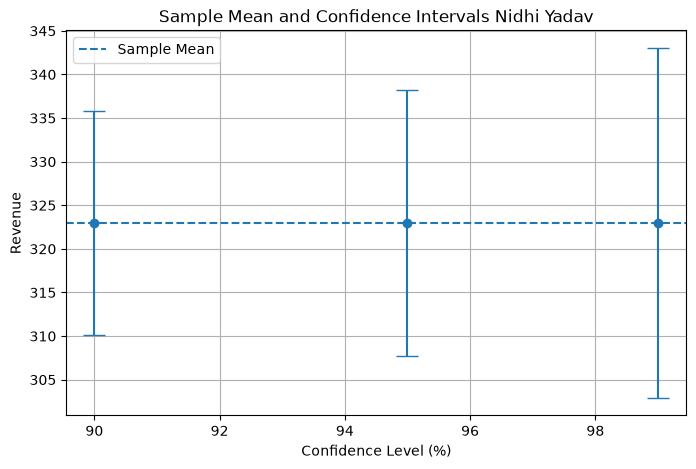

In [27]:
confidence_levels = [90, 95, 99]
lower_values = [
    ci_90[0],
    ci_95[0],
    ci_99[0]
]
upper_values = [
    ci_90[1],
    ci_95[1],
    ci_99[1]
]
errors_lower = [
    sample_mean - ci_90[0],
    sample_mean - ci_95[0],
    sample_mean - ci_99[0]
]
errors_upper = [
    ci_90[1] - sample_mean,
    ci_95[1] - sample_mean,
    ci_99[1] - sample_mean
]
plt.figure(figsize=(8, 5))
plt.errorbar(
    confidence_levels,
    [sample_mean] * 3,
    yerr=[errors_lower, errors_upper],
    fmt='o',
    capsize=8
)
plt.axhline(
    sample_mean,
    linestyle='--',
    label="Sample Mean"
)
plt.xlabel("Confidence Level (%)")
plt.ylabel("Revenue")
plt.title("Sample Mean and Confidence Intervals Nidhi Yadav")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
print("\nInterpretation of 95% Confidence Interval:")
print(
    "We are 95% confident that the true population mean "
    "revenue lies between",
    round(ci_95[0], 2),
    "and",
    round(ci_95[1], 2)
)



Interpretation of 95% Confidence Interval:
We are 95% confident that the true population mean revenue lies between 307.71 and 338.23


In [30]:
customer_type = df["Customer type"]

print("\nCustomer Type Counts:")
print(customer_type.value_counts())

print("\nCustomer Type Proportions:")
proportions = customer_type.value_counts(normalize=True)

print(proportions)


Customer Type Counts:
Customer type
Member    501
Normal    499
Name: count, dtype: int64

Customer Type Proportions:
Customer type
Member    0.501
Normal    0.499
Name: proportion, dtype: float64


In [31]:

total_customers = len(customer_type)

member_count = (customer_type == "Member").sum()

member_proportion = member_count / total_customers

# Standard error for proportion
proportion_se = np.sqrt(
    member_proportion * (1 - member_proportion)
    / total_customers
)

# 95% confidence interval using normal approximation
z = stats.norm.ppf(0.975)

proportion_lower = member_proportion - z * proportion_se
proportion_upper = member_proportion + z * proportion_se

# Keep limits between 0 and 1
proportion_lower = max(0, proportion_lower)
proportion_upper = min(1, proportion_upper)


print("\nMember Customers:", member_count)
print("Total Customers:", total_customers)
print("Member Proportion:", round(member_proportion, 4))

print("\n95% Confidence Interval for Member Proportion:")
print(
    round(proportion_lower, 4),
    "to",
    round(proportion_upper, 4)
)

print(
    "Percentage:",
    round(proportion_lower * 100, 2),
    "% to",
    round(proportion_upper * 100, 2),
    "%"
)



Member Customers: 501
Total Customers: 1000
Member Proportion: 0.501

95% Confidence Interval for Member Proportion:
0.47 to 0.532
Percentage: 47.0 % to 53.2 %


In [32]:
print("\nBusiness Interpretation:")
print(
    "We are 95% confident that the true proportion "
    "of Member customers lies between",
    round(proportion_lower * 100, 2),
    "% and",
    round(proportion_upper * 100, 2),
    "%"
)


Business Interpretation:
We are 95% confident that the true proportion of Member customers lies between 47.0 % and 53.2 %


Part B

In [33]:
original_median = revenue.median()
print("\nOriginal Sample Median:", round(original_median, 2))




Original Sample Median: 253.85


In [34]:
np.random.seed(42)

bootstrap_medians = []

# 1000 bootstrap samples
for i in range(1000):

    # 17. Create bootstrap sample
    bootstrap_sample = np.random.choice(
        revenue,
        size=len(revenue),
        replace=True
    )

    # 18. Calculate median
    bootstrap_median = np.median(bootstrap_sample)

    # 19. Store median
    bootstrap_medians.append(bootstrap_median)


# Convert to NumPy array
bootstrap_medians = np.array(bootstrap_medians)

print("\nNumber of Bootstrap Samples:",
      len(bootstrap_medians))



Number of Bootstrap Samples: 1000


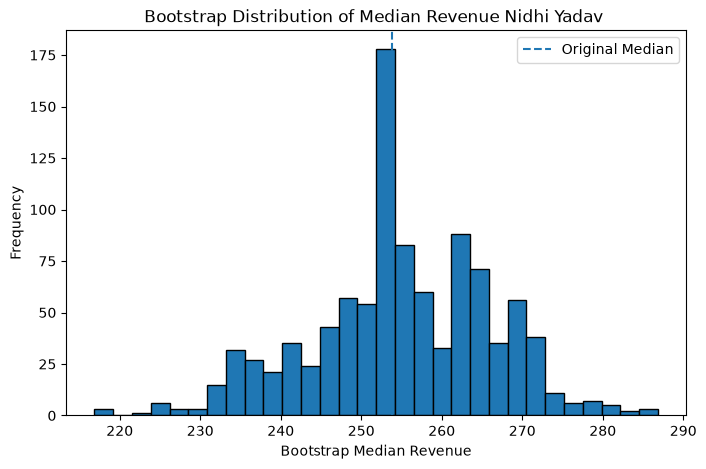

In [43]:

plt.figure(figsize=(8, 5))

plt.hist(
    bootstrap_medians,
    bins=30,
    edgecolor="black"
)

plt.axvline(
    original_median,
    linestyle="--",
    label="Original Median"
)

plt.xlabel("Bootstrap Median Revenue")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of Median Revenue Nidhi Yadav ")
plt.legend()
plt.show()


In [36]:

lower_percentile = np.percentile(
    bootstrap_medians,
    2.5
)

upper_percentile = np.percentile(
    bootstrap_medians,
    97.5
)

print("\n2.5th Percentile:",
      round(lower_percentile, 2))

print("97.5th Percentile:",
      round(upper_percentile, 2))



2.5th Percentile: 232.87
97.5th Percentile: 273.61


In [37]:

bootstrap_ci = (
    lower_percentile,
    upper_percentile
)

print("\n95% Bootstrap Confidence Interval:")
print(
    round(bootstrap_ci[0], 2),
    "to",
    round(bootstrap_ci[1], 2)
)


95% Bootstrap Confidence Interval:
232.87 to 273.61


In [38]:
print("\nOriginal Sample Median:",
      round(original_median, 2))

print(
    "Bootstrap 95% Confidence Interval:",
    round(bootstrap_ci[0], 2),
    "to",
    round(bootstrap_ci[1], 2)
)


Original Sample Median: 253.85
Bootstrap 95% Confidence Interval: 232.87 to 273.61


In [39]:
print("\nComparison:")

if bootstrap_ci[0] <= original_median <= bootstrap_ci[1]:
    print(
        "The original sample median lies inside "
        "the bootstrap confidence interval."
    )
else:
    print(
        "The original sample median lies outside "
        "the bootstrap confidence interval."
    )


Comparison:
The original sample median lies inside the bootstrap confidence interval.


In [40]:
print("\nBusiness Interpretation:")
print(
    "The bootstrap confidence interval gives an estimated "
    "range for the true population median revenue."
)

print(
    "The estimated population median revenue is between",
    round(bootstrap_ci[0], 2),
    "and",
    round(bootstrap_ci[1], 2)
)


Business Interpretation:
The bootstrap confidence interval gives an estimated range for the true population median revenue.
The estimated population median revenue is between 232.87 and 273.61


In [41]:
print("\nCONCLUSION:")
print(
    "Confidence intervals help businesses estimate the "
    "population mean and customer proportions from sample data."
)

print(
    "Bootstrapping helps estimate the confidence interval "
    "of statistics such as the median without assuming "
    "a specific data distribution."
)

print(
    "These methods help businesses make better decisions "
    "using sample data."
)


CONCLUSION:
Confidence intervals help businesses estimate the population mean and customer proportions from sample data.
Bootstrapping helps estimate the confidence interval of statistics such as the median without assuming a specific data distribution.
These methods help businesses make better decisions using sample data.
